#### Inicializacion de GPU

In [5]:
#!unzip Dataset_TrashUp.zip

Archive:  Dataset_TrashUp.zip
   creating: Dataset_TrashUp/
   creating: Dataset_TrashUp/Carton_Papel/
  inflating: Dataset_TrashUp/Carton_Papel/carton (1).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1).png  
  inflating: Dataset_TrashUp/Carton_Papel/carton (101).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1011).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1012).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1019).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1020).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1021).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1022).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1023).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1024).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1025).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1026).jpg  
  inflating: Dataset_TrashUp/Carton_Papel/carton (1027).jpg  
  inflating: Dataset_TrashUp/Carton_

In [5]:
# import os
# import pandas as pd
# import numpy as np
# from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img

# # =============================
# # Parámetros
# # =============================
# dataset_dir = './Dataset_TrashUp/'
# AUGMENT_SIZE = 600  # cantidad de imágenes aumentadas que querés generar
# CLASS_NAME = "Varios_Plastico"  # nombre exacto de la carpeta/clase
# ORIGINAL_DIR = os.path.join(dataset_dir, CLASS_NAME)  # carpeta original de la clase
# IMG_SIZE = 224  # o el que estés usando

# # =============================
# # Cargar imágenes originales
# # =============================
# image_paths = [os.path.join(ORIGINAL_DIR, fname) for fname in os.listdir(ORIGINAL_DIR) if fname.lower().endswith(('.jpg', '.jpeg', '.png'))]

# # Tomar imágenes aleatorias para aumentar
# np.random.seed(42)
# sample_paths = np.random.choice(image_paths, size=AUGMENT_SIZE, replace=True)

# # =============================
# # Definir transformaciones
# # =============================
# augmenter = ImageDataGenerator(
#     rotation_range=20,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     shear_range=0.1,
#     zoom_range=0.2,
#     horizontal_flip=True,
#     fill_mode='nearest'
# )

# # =============================
# # Generar y guardar imágenes
# # =============================
# print(f"Generando {AUGMENT_SIZE} imágenes aumentadas en: {ORIGINAL_DIR}")

# for i, img_path in enumerate(sample_paths):
#     img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
#     img_array = img_to_array(img)
#     img_array = np.expand_dims(img_array, axis=0)

#     prefix = f"aug_{i:04d}"
#     save_prefix = os.path.splitext(os.path.basename(img_path))[0] + f"_{prefix}"

#     # flow() genera y guarda automáticamente
#     for batch in augmenter.flow(img_array, batch_size=1,
#                                 save_to_dir=ORIGINAL_DIR,
#                                 save_prefix=save_prefix,
#                                 save_format='jpg'):
#         break  # solo una imagen por iteración

# print("✅ Data augmentation completado.")

Generando 600 imágenes aumentadas en: ./Dataset_TrashUp/Varios_Plastico
✅ Data augmentation completado.


In [1]:
import tensorflow as tf
import os
# Optional: Silence excessive logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Detect GPU
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print("❌ No GPU detected. Exiting.")
    exit(1)
else:
    print("✅  GPU Detected! ")
# gpus = tf.config.list_physical_devices('GPU')
#
# try:
#     tf.config.set_logical_device_configuration(
#         gpus[0],
#         [tf.config.LogicalDeviceConfiguration(memory_limit=8192)]  # 6 GB
#     )
#     print("✅ GPU limited to 6 GB.")
# except RuntimeError as e:
#     print(f"⚠️ Could not set memory limit: {e}")
#     exit(1)
#
# # Run a simple matrix multiplication on the GPU
# @tf.function
# def gpu_workload():
#     with tf.device('/GPU:0'):
#         a = tf.random.normal([4096, 4096])
#         b = tf.random.normal([4096, 4096])
#         c = tf.matmul(a, b)
#         return tf.reduce_sum(c)

# # Trigger the workload
# result = gpu_workload()

# print("✅ GPU is working perfectly. Result:", result.numpy())

# del result
# import gc
# gc.collect()

2025-07-22 21:57:46.757193: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-22 21:57:46.757220: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-22 21:57:46.757249: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-22 21:57:46.763632: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅  GPU Detected! 


2025-07-22 21:57:48.504328: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-22 21:57:48.508898: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-22 21:57:48.509195: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [2]:
print("GPUs: ", len(tf.config.experimental.list_physical_devices('GPU')))

GPUs:  1


In [3]:
print("CUDA disponibles: ", tf.test.is_built_with_cuda())

CUDA disponibles:  True


In [4]:
print("Tensorflow version: ", tf.version.VERSION)

Tensorflow version:  2.14.0


#### Clasificacion

Inserte su codigo a partir de esta linea

In [5]:
# !pip install pandas numpy matplotlib scikit-learn scipy

In [6]:
import os
import scipy
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import mlflow
import mlflow.keras
import random
import datetime
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [7]:
# Semilla
RANDOM_STATE = 50
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [8]:
mlflow.autolog()
mlflow.set_tracking_uri("http://mlflow_server:5000")

2025/07/22 21:57:53 INFO mlflow.tracking.fluent: Autologging successfully enabled for keras.
2025/07/22 21:57:53 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/07/22 21:57:53 INFO mlflow.tracking.fluent: Autologging successfully enabled for tensorflow.


In [9]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.00001

In [10]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Ruta base del dataset
dataset_dir = './Dataset_TrashUp/'

# Crear un único DataFrame con todas las imágenes y etiquetas
def create_dataframe(directory):
    filepaths = []
    labels = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                label = os.path.basename(root)
                filepaths.append(os.path.join(root, file))
                labels.append(label)

    return pd.DataFrame({'image_path': filepaths, 'label': labels})

# Crear el dataframe completo
df = create_dataframe(dataset_dir)

# Primer split: train vs temp (valid + test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,  # 30% para valid+test
    stratify=df['label'],
    random_state=RANDOM_STATE
)

# Segundo split: valid vs test
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # mitad para valid, mitad para test (15% y 15%)
    stratify=temp_df['label'],
    random_state=RANDOM_STATE
)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape:", test_df.shape)

Train shape: (8281, 2)
Valid shape: (1775, 2)
Test shape: (1775, 2)


In [11]:
# Start MLflow tracking
mlflow.set_experiment("resnet50")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1752801109741, experiment_id='1', last_update_time=1752801109741, lifecycle_stage='active', name='resnet50', tags={}>

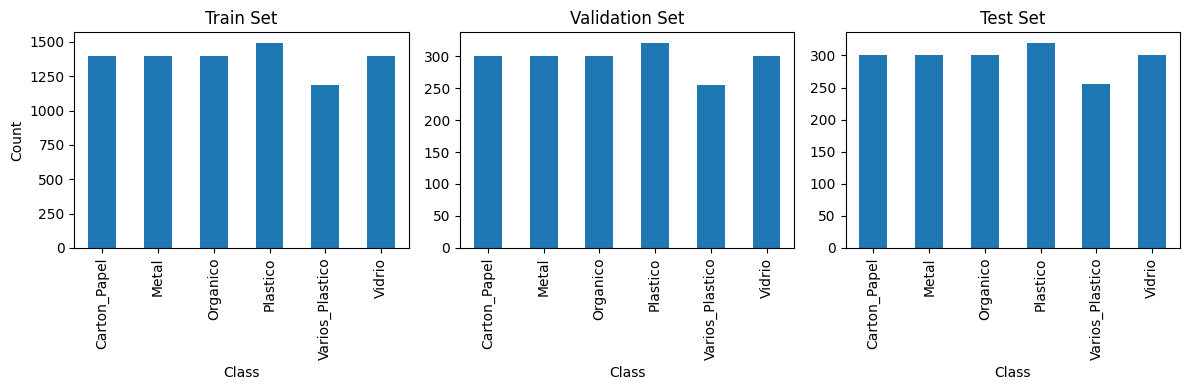

In [12]:
# =============================
# 4. Gráfico de distribución
# =============================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
train_df['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Train Set')
plt.xlabel('Class')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
valid_df['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Validation Set')
plt.xlabel('Class')

plt.subplot(1, 3, 3)
test_df['label'].value_counts().sort_index().plot(kind='bar')
plt.title('Test Set')
plt.xlabel('Class')

plt.tight_layout()
plt.show()


In [13]:
# =============================
# 5. Generadores de imágenes
# =============================
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=RANDOM_STATE
)

valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=RANDOM_STATE
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=RANDOM_STATE
)



Found 8281 validated image filenames belonging to 6 classes.
Found 1775 validated image filenames belonging to 6 classes.
Found 1775 validated image filenames belonging to 6 classes.


In [14]:
# =============================
# 6. Modelo basado en ResNet50
# =============================
from tensorflow.keras import regularizers

base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))

for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(len(train_generator.class_indices), activation='softmax')
])

base_model.summary()

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

2025-07-22 21:57:58.389374: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-22 21:57:58.389562: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-22 21:57:58.389699: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                       

2025/07/22 21:58:12 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.preprocessing.image.DataFrameIterator'>. Dataset logging skipped.
2025/07/22 21:58:12 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.preprocessing.image.DataFrameIterator'>. Dataset logging skipped.


Epoch 1/25


2025-07-22 21:58:16.641436: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2025-07-22 21:58:18.758444: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f1649a70650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-22 21:58:18.758551: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2025-07-22 21:58:18.763044: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-07-22 21:58:18.853299: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


259/259 [==============================] - ETA: 0s - loss: 2.0583 - accuracy: 0.2492

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


259/259 [==============================] - 39s 125ms/step - loss: 2.0583 - accuracy: 0.2492 - val_loss: 1.7512 - val_accuracy: 0.2772
Epoch 2/25
259/259 [==============================] - 28s 108ms/step - loss: 1.8139 - accuracy: 0.3194 - val_loss: 2.1425 - val_accuracy: 0.2749
Epoch 3/25
259/259 [==============================] - 30s 115ms/step - loss: 1.7118 - accuracy: 0.3556 - val_loss: 1.4771 - val_accuracy: 0.4473
Epoch 4/25
259/259 [==============================] - 29s 111ms/step - loss: 1.6203 - accuracy: 0.3817 - val_loss: 1.5036 - val_accuracy: 0.4620
Epoch 5/25
259/259 [==============================] - 30s 115ms/step - loss: 1.5724 - accuracy: 0.3974 - val_loss: 1.3190 - val_accuracy: 0.4958
Epoch 6/25
259/259 [==============================] - 29s 110ms/step - loss: 1.5240 - accuracy: 0.4159 - val_loss: 1.3767 - val_accuracy: 0.4569
Epoch 7/25
259/259 [==============================] - 28s 109ms/step - loss: 1.5004 - accuracy: 0.4201 - val_loss: 1.4055 - val_accuracy: 0.4

2025/07/22 22:06:19 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: '>=' not supported between instances of 'slice' and 'int'
2025/07/22 22:06:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/22 22:06:19 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: /tmp/tmp63p4ldfd/model/data/model/assets


INFO:tensorflow:Assets written to: /tmp/tmp63p4ldfd/model/data/model/assets
2025/07/22 22:06:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


56/56 [==============================] - 4s 78ms/step - loss: 1.2521 - accuracy: 0.5076
Test accuracy: 0.5076
56/56 [==============================] - 5s 77ms/step
                 precision    recall  f1-score   support

   Carton_Papel       0.45      0.34      0.39       300
          Metal       0.62      0.20      0.30       300
       Organico       0.82      0.70      0.76       300
       Plastico       0.39      0.74      0.51       320
Varios_Plastico       0.56      0.74      0.64       255
         Vidrio       0.42      0.34      0.37       300

       accuracy                           0.51      1775
      macro avg       0.54      0.51      0.49      1775
   weighted avg       0.54      0.51      0.49      1775



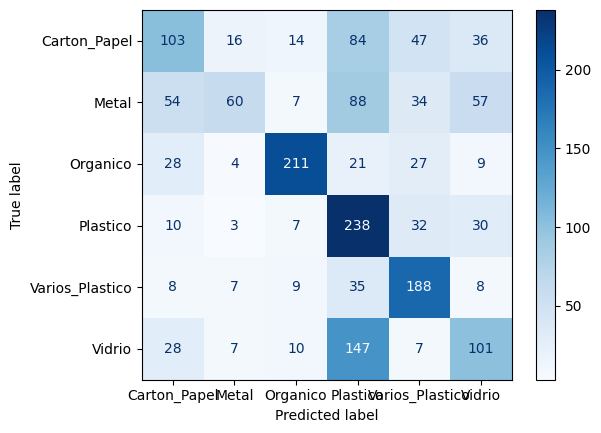

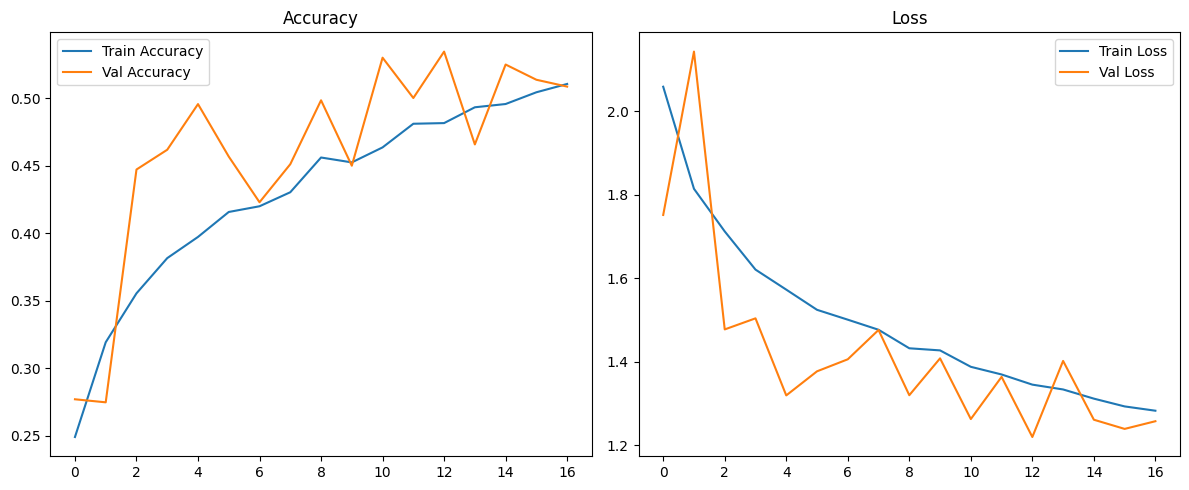

🏃 View run 2025-07-22_21-58-12 at: http://mlflow_server:5000/#/experiments/1/runs/9705cea448794481aa047f363a79620f
🧪 View experiment at: http://mlflow_server:5000/#/experiments/1


In [15]:
# =============================
# 7. Entrenamiento del modelo
# =============================
# Log parameters, metrics, and model
run_name = f"{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"

with mlflow.start_run(run_name=run_name):
    
    es = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=valid_generator,
        callbacks=[es]
    )

    # =============================
    # 8. Evaluación y métricas
    # =============================
    
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Test accuracy: {test_acc:.4f}")
    
    # Predicciones
    preds = model.predict(test_generator)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_generator.classes
    class_names = list(test_generator.class_indices.keys())
    
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Matriz de confusión
    conf_matrix = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(conf_matrix, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.show()

    # =============================
    # 9. Gráficas de entrenamiento
    # =============================
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))
    
    # Loguear métricas finales en MLflow
    metrics = {
        "accuracy_train": acc[-1],
        "accuracy_valid": val_acc[-1],
        "loss_train": loss[-1],
        "loss_valid": val_loss[-1],
        "accuracy_test": test_acc,
        "loss_test": test_loss
    }
    
    for key, value in metrics.items():
        mlflow.log_metric(key, value)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.title('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [31]:
# =============================
# Fine Tunning
# =============================
from tensorflow.keras import regularizers

base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))

for layer in base_model.layers[-4:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(len(train_generator.class_indices), activation='softmax')
])

base_model.summary()

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_17 (InputLayer)       [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_17[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                       

2025/07/22 22:13:46 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.preprocessing.image.DataFrameIterator'>. Dataset logging skipped.
2025/07/22 22:13:46 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.preprocessing.image.DataFrameIterator'>. Dataset logging skipped.


Epoch 1/25
  6/259 [..............................] - ETA: 1:05 - loss: 2.3748 - accuracy: 0.1875WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.1120s vs `on_train_batch_end` time: 0.1525s). Check your callbacks.


259/259 [==============================] - ETA: 0s - loss: 1.3982 - accuracy: 0.4881

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


259/259 [==============================] - 100s 292ms/step - loss: 1.3982 - accuracy: 0.4881 - val_loss: 2.2905 - val_accuracy: 0.1837
Epoch 2/25
259/259 [==============================] - 73s 282ms/step - loss: 0.7858 - accuracy: 0.7396 - val_loss: 1.6063 - val_accuracy: 0.3577
Epoch 3/25
259/259 [==============================] - 73s 282ms/step - loss: 0.6071 - accuracy: 0.8183 - val_loss: 0.8306 - val_accuracy: 0.7042
Epoch 4/25
259/259 [==============================] - 73s 283ms/step - loss: 0.4941 - accuracy: 0.8724 - val_loss: 0.3603 - val_accuracy: 0.9161
Epoch 5/25
259/259 [==============================] - 73s 283ms/step - loss: 0.4253 - accuracy: 0.9011 - val_loss: 0.2778 - val_accuracy: 0.9465
Epoch 6/25
259/259 [==============================] - 73s 281ms/step - loss: 0.3727 - accuracy: 0.9157 - val_loss: 0.2414 - val_accuracy: 0.9504
Epoch 7/25
259/259 [==============================] - 72s 279ms/step - loss: 0.3235 - accuracy: 0.9355 - val_loss: 0.2143 - val_accuracy: 0.

2025/07/22 22:39:13 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: '>=' not supported between instances of 'slice' and 'int'
2025/07/22 22:39:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/22 22:39:13 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: /tmp/tmp5x1cxs40/model/data/model/assets


INFO:tensorflow:Assets written to: /tmp/tmp5x1cxs40/model/data/model/assets
2025/07/22 22:39:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


56/56 [==============================] - 5s 84ms/step - loss: 0.1281 - accuracy: 0.9679
Test accuracy: 0.9679
56/56 [==============================] - 5s 82ms/step
                 precision    recall  f1-score   support

   Carton_Papel       0.95      0.97      0.96       300
          Metal       0.98      0.98      0.98       300
       Organico       0.97      0.99      0.98       300
       Plastico       0.98      0.95      0.96       320
Varios_Plastico       0.98      0.97      0.97       255
         Vidrio       0.96      0.94      0.95       300

       accuracy                           0.97      1775
      macro avg       0.97      0.97      0.97      1775
   weighted avg       0.97      0.97      0.97      1775



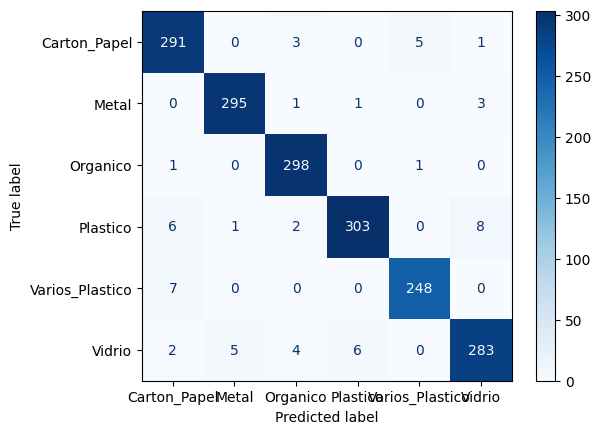

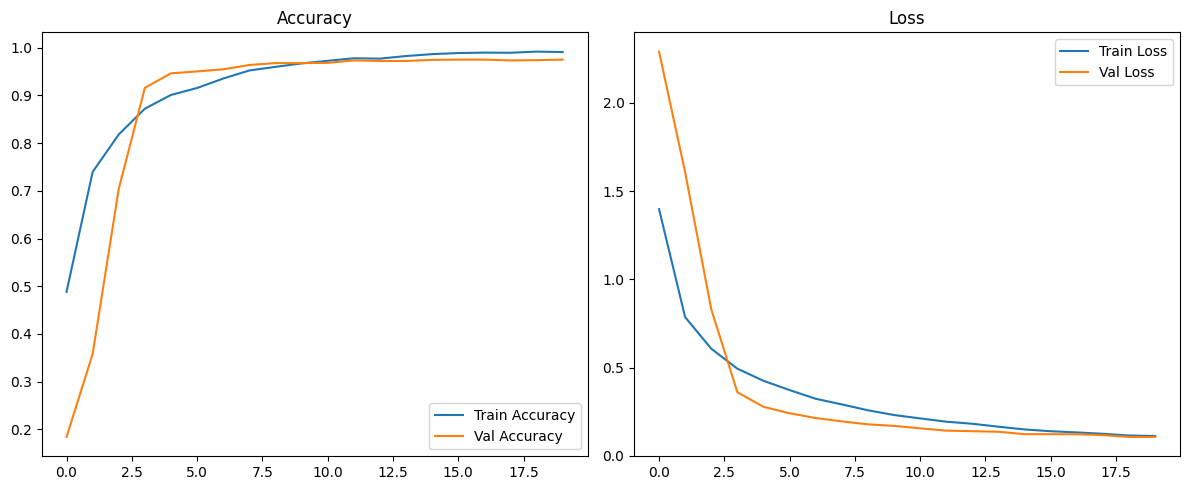

🏃 View run 2025-07-22_22-13-46 at: http://mlflow_server:5000/#/experiments/1/runs/02c51326448a4ac69b6ab941f4ce85ff
🧪 View experiment at: http://mlflow_server:5000/#/experiments/1


In [32]:
# =============================
# Entrenamiento del modelo
# =============================
# Log parameters, metrics, and model
run_name = f"{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"

with mlflow.start_run(run_name=run_name):
    
    es = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)

    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=valid_generator,
        callbacks=[es]
    )

    # =============================
    # Evaluación y métricas
    # =============================
    
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Test accuracy: {test_acc:.4f}")
    
    # Predicciones
    preds = model.predict(test_generator)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_generator.classes
    class_names = list(test_generator.class_indices.keys())
    
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Matriz de confusión
    conf_matrix = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(conf_matrix, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.show()

    # =============================
    # Gráficas de entrenamiento
    # =============================
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))
    
    # Loguear métricas finales en MLflow
    metrics = {
        "accuracy_train": acc[-1],
        "accuracy_valid": val_acc[-1],
        "loss_train": loss[-1],
        "loss_valid": val_loss[-1],
        "accuracy_test": test_acc,
        "loss_test": test_loss
    }
    
    for key, value in metrics.items():
        mlflow.log_metric(key, value)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.title('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

Total imágenes mal clasificadas: 57


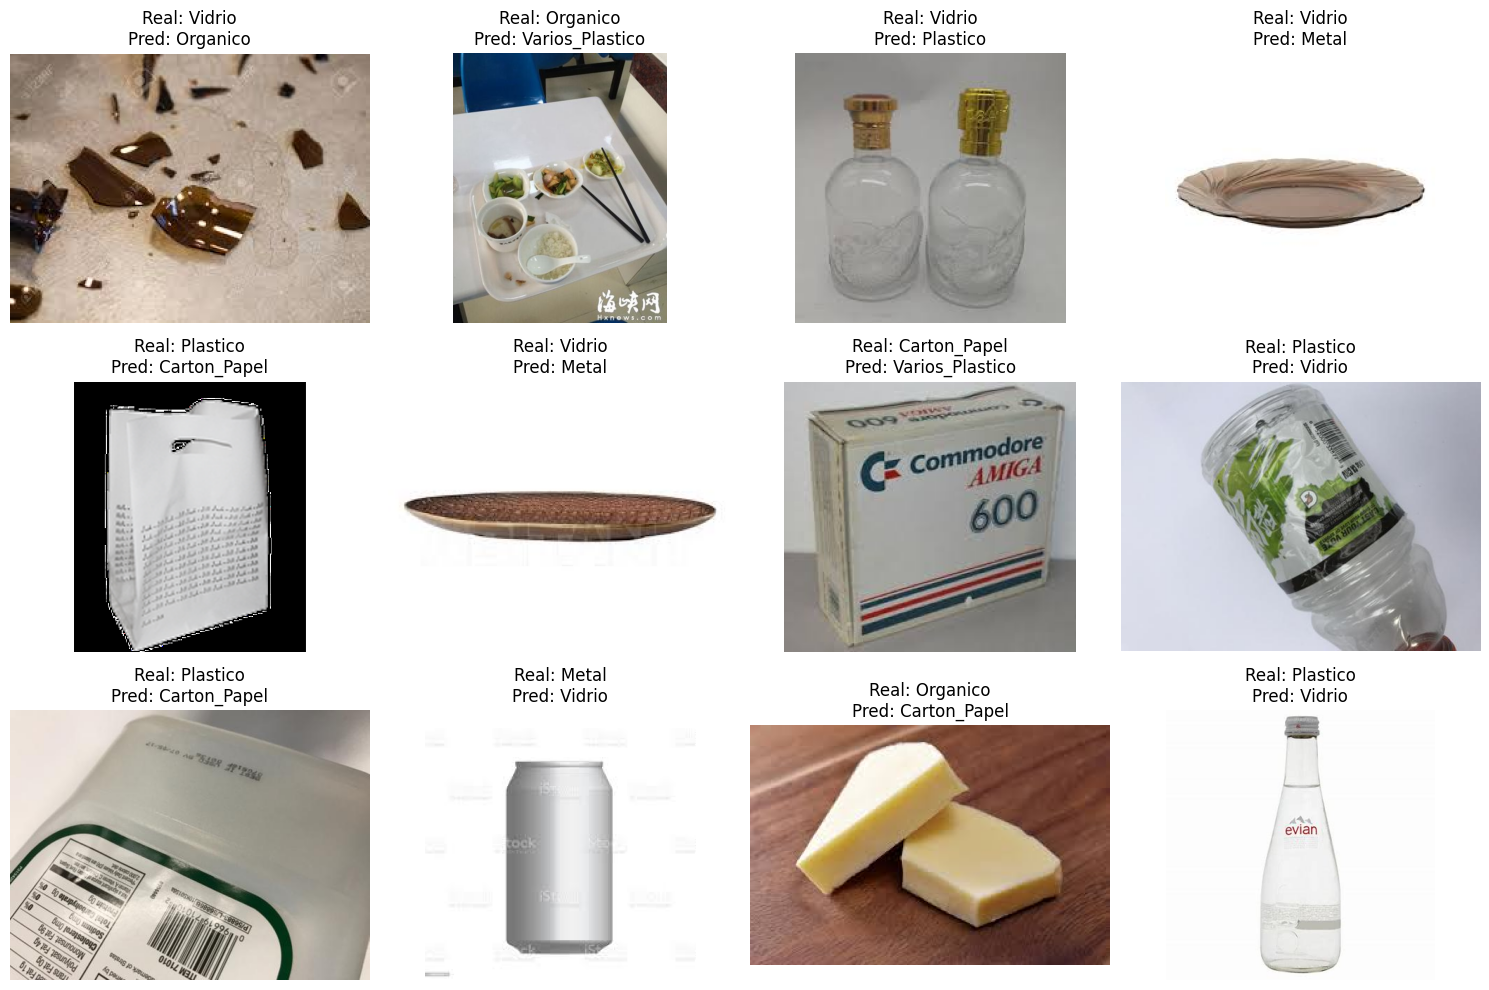

In [33]:
# =============================
# Visualizar imágenes mal clasificadas
# =============================

# Obtener rutas de las imágenes del test
file_paths = test_generator.filepaths

# Índices donde la predicción es incorrecta
incorrect_indices = np.where(y_pred != y_true)[0]

print(f"Total imágenes mal clasificadas: {len(incorrect_indices)}")

# Mostrar algunas imágenes mal clasificadas
num_to_show = min(12, len(incorrect_indices))  # Cambiá este número si querés ver más o menos
plt.figure(figsize=(15, 10))

for i, idx in enumerate(incorrect_indices[:num_to_show]):
    img_path = file_paths[idx]
    img = plt.imread(img_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [34]:
# =============================
# Guardar modelo
# =============================
import uuid
model.save(f'./models/trashup_model_V7_resnet50.h5')
print(f"Modelo trashup_model_resnet50.h5 guardado con exito!")

/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Modelo trashup_model_resnet50.h5 guardado con exito!
